# Importing Libraries

In [1]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


col_to_name = dict()
col_to_name["date"] = "date"
col_to_name["Appliance"] = "Power used by appliances(Wh)"
col_to_name["lights"] = "energy consumed by lights(wh)"

col_to_name["T1"] = "Temp in kitchen(Celsius)"
col_to_name["RH_1"] = "Humidity in kitchen(%)"

col_to_name["T2"] = "Temp in living room(Celsius)"
col_to_name["RH_2"] = "Humidity in living room(%)"

col_to_name["T3"] = "Temp in laundry room(Celsius)"
col_to_name["RH_3"] = "Humidity in laundry room(%)"

col_to_name["T4"] = "Temp in office room(Celsius)"
col_to_name["RH_4"] = "Humidity in office room(%)"

col_to_name["T5"] = "Temp in bathroom(Celsius)"
col_to_name["RH_5"] = "Humidity in bathroom(%)"

col_to_name["T6"] = "Temp in outside the building, north side(Celsius)"
col_to_name["RH_6"] = "Humidity in outside the building, north side(%)"

col_to_name["T7"] = "Temp in ironing room(Celsius)"
col_to_name["RH_7"] = "Humidity in ironing room(%)"

col_to_name["T8"] = "Temp in teenager room(Celsius)"
col_to_name["RH_8"] = "Humidity in teenager room(%)"

col_to_name["T9"] = "Temp in parents room(Celsius)"
col_to_name["RH_9"] = "Humidity in parents room(%)"


col_to_name["T_out"] = "Temp outside, from weather station(Celsius)"
col_to_name["RH_out"] = "Humidity outside, from weather station(%)"


col_to_name["Press_mm_hg"] = "Presssure measured from weather station(Hg)"
col_to_name['Windspeed'] = "Windspeed from weather station(m/s)"

col_to_name['Visibility'] = "Visibility measured from weather station(km)" # How far things can seen with the current weather
col_to_name["Tdewpoint"] = "Dew point temp(C)"

col_to_name["rv1"] = "Random varable 1"
col_to_name["rv2"] = "Random variable 2"

# Data Loading and Audit


In [2]:
df = pd.read_csv("../data/energydata_complete.csv")
print(df.head())

print("\n\n----------------------------------------------------------\n\n")
print(f"No.of Rows: {df.shape[0]}")
print(f"No.of columns: {df.shape[1]}")
print("\n\n----------------------------------------------------------\n\n")

print("\nColumn Names:")
print(df.columns.tolist())


print("\n\n----------------------------------------------------------\n\n")

print("Missing Values:")
print(df.isnull().sum().sum())

print("\nMissing Values per feature:")
print(df.isnull().sum())

print("\n\n----------------------------------------------------------\n\n")

print("Target Distribution:")
print(df["Appliances"].value_counts())

print("\n\n----------------------------------------------------------\n\n")

print("Dataset Information:")
df.info()


                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspeed  Visibility

# Functions

In [3]:
def get_df():
    df = pd.read_csv("../data/energydata_complete.csv")
    return df

def rm_empty_rows(df):
    df = df.copy()
    df = df.dropna()
    return df

def seperate_target(df):
    df = df.copy()
    cols = df.columns
    cols = list(cols)
    cols.remove("Appliances")
    target = df.drop(cols,axis=1,inplace=False)
    df.drop('Appliances', axis=1, inplace=True)
    return (target, df)


def standardization(df, cols):
    df = df.copy()
    scaler = sk.preprocessing.StandardScaler()
    for col in cols:
        df[col] = scaler.fit_transform(df[[col]])

    return df


def normalization(df, cols):
    df = df.copy()
    scaler = sk.preprocessing.MinMaxScaler()
    for col in cols:
        df[col] = scaler.fit_transform(df[[col]])

    return df

def get_split(target, df, test_size):
    df = df.copy()
    x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(df,target,test_size=test_size,random_state=42)
    return (x_train, x_test, y_train, y_test)

    
def get_regression_scores(y_test,y_pred):
    r2 = sk.metrics.r2_score(y_test, y_pred)
    rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred))
    mae = sk.metrics.mean_absolute_error(y_test, y_pred)
    return (r2, rmse, mae)




def remove_highly_correlated_variables(df, threshold):
    df = df.copy()
    corr = df.corr()
    to_drop = set()
    correlation_threshold = threshold
    print("\n\n---------------------------------\n\n")
    print(f"Highly correlated features (correlation above: {correlation_threshold}):")

    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            value = corr.iloc[i, j]
            if abs(value) > correlation_threshold:
                col1 = corr.columns[i]
                col2 = corr.columns[j]

                print(col1, "<->", col2, ":", value)

                to_drop.add(col1)
            
    #print(f"Removed features: {to_drop}")
    #print("\n\n---------------------------------\n\n")

    df.drop(columns=list(to_drop), inplace=True)
    
    return df



def apply_pca(x_train, x_test, variance):

    scaler = sk.preprocessing.StandardScaler()
    scaler.fit(x_train)
    pca = sk.decomposition.PCA(n_components=variance)
    x_train_scaled = scaler.transform(x_train)
    pca.fit(x_train_scaled)

    x_train_scaled = scaler.transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    x_train_pca = pca.transform(x_train_scaled)
    x_test_pca = pca.transform(x_test_scaled)
    """
    print("\n\n---------------------------------------\n\n")
    print("Original features:", x_train.shape[1])
    print("PCA features:", x_train_pca.shape[1])
    print("Explained variance:", pca.explained_variance_ratio_)
    print("Total variance retained:", pca.explained_variance_ratio_.sum())
    print("\n\n---------------------------------------\n\n")
    """

    return x_train_pca, x_test_pca, scaler, pca




def remove_outliers(df,columns):
    df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        removed = df[
            (df[col] > upper) |
            (df[col] < lower)
        ]

        


        #print("\n\n--------------------------\n\n")
        #print(f"Removed outliers in {col}: ")
        #print("Shape of removed values: ", removed.shape)
        #print(removed.head())
        #print("\n\n--------------------------\n\n")


        df = df[
            (df[col] >= lower) &
            (df[col] <= upper)
        ]
    return df

def winsorize_outliers(df, columns):
    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = (
            (df[col] < lower) |
            (df[col] > upper)
        )

        #print(f"\n{col}")
        #print("Outliers:", outliers.sum())

        # Cap values
        df[col] = df[col].clip(
            lower=lower,
            upper=upper
        )

    return df

def replace_outliers_with_mean(df, columns):
    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = (
            (df[col] < lower) |
            (df[col] > upper)
        )

        #print(f"\n{col}")
        #print("Outliers:", outliers.sum())

        # Calculate mean excluding outliers
        mean = df.loc[~outliers, col].mean()

        # Replace outliers
        df.loc[outliers, col] = mean

    return df

    

# Exploratory Data Analysis(EDA)

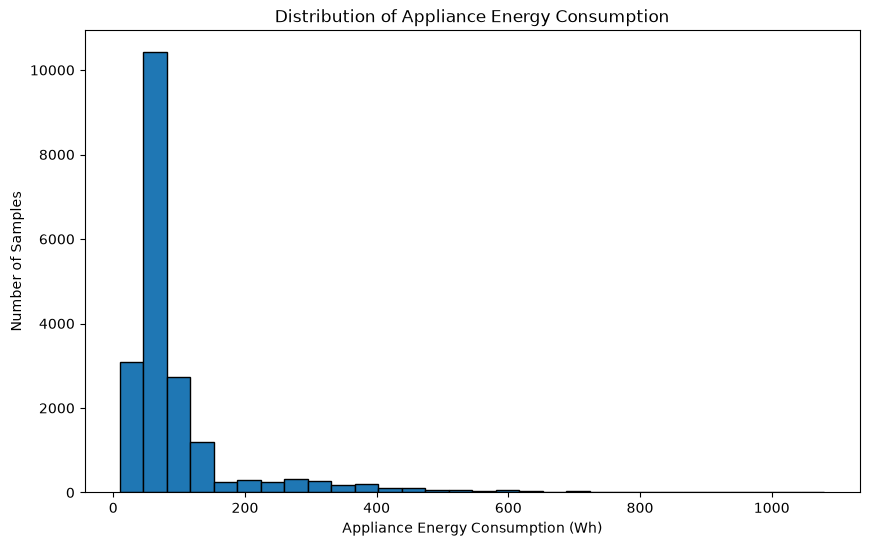



------------------------------------------




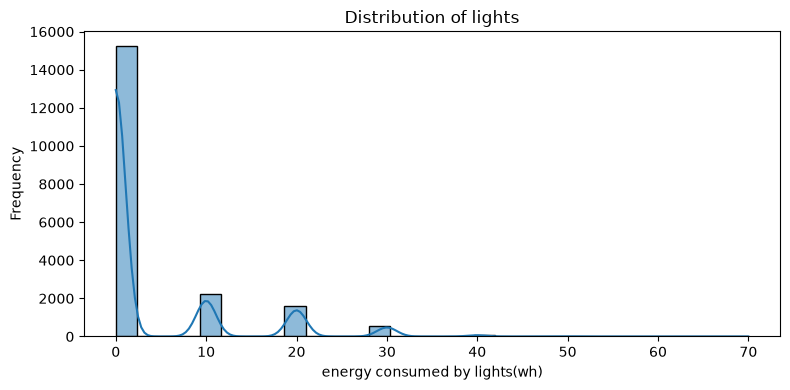

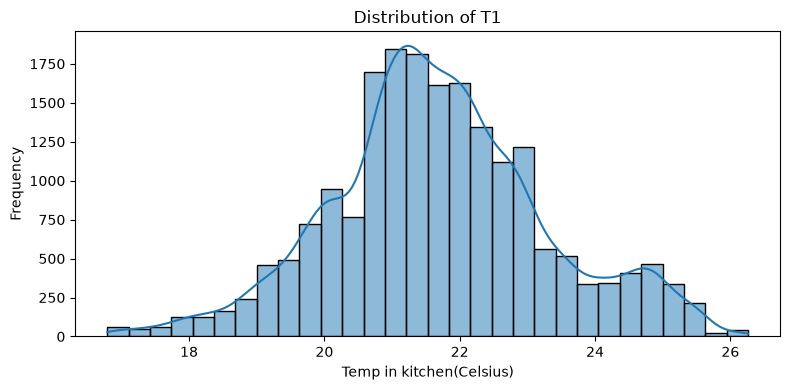

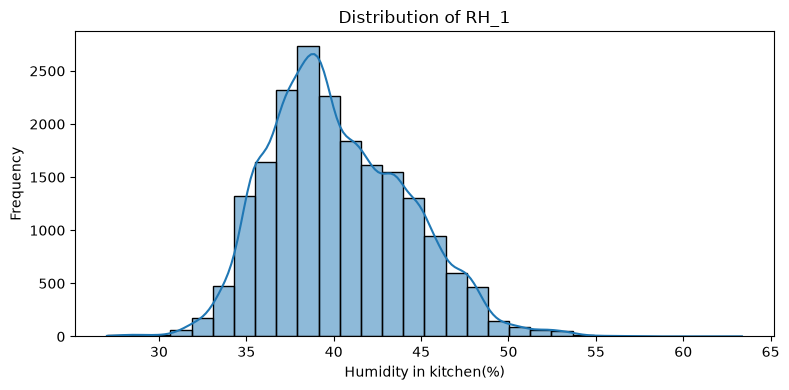

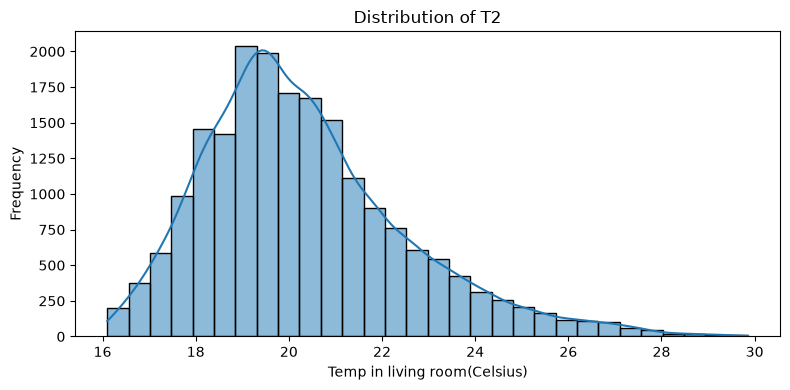

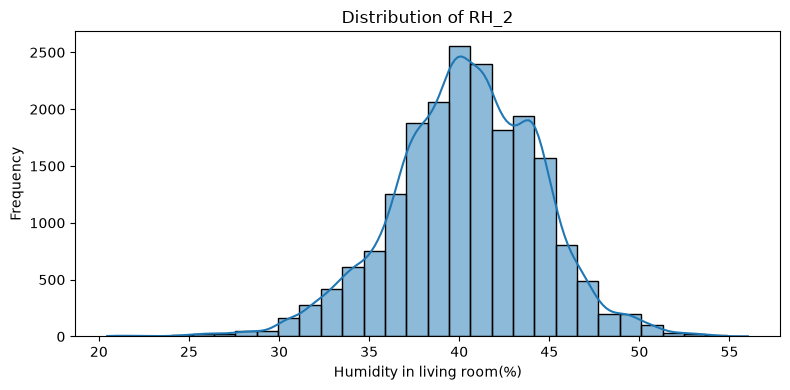

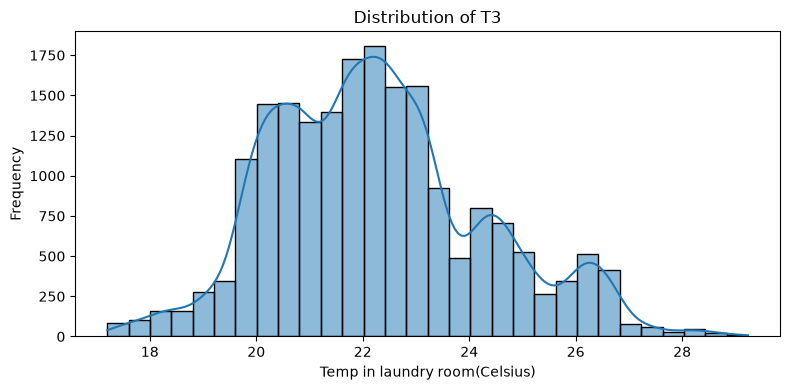

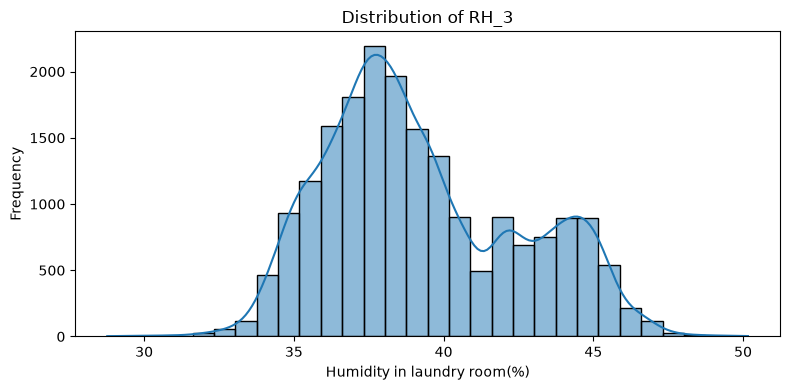

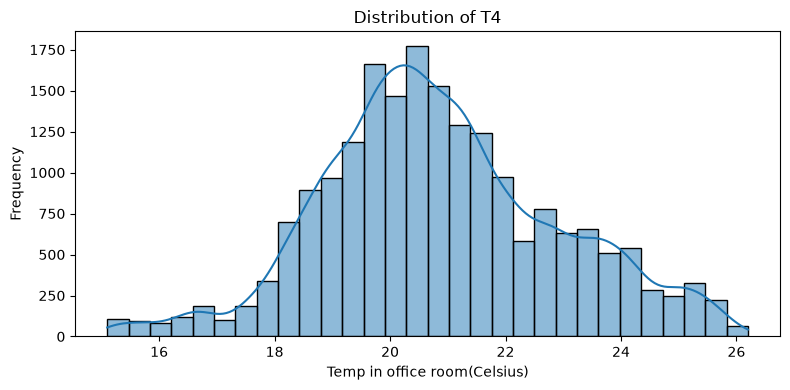

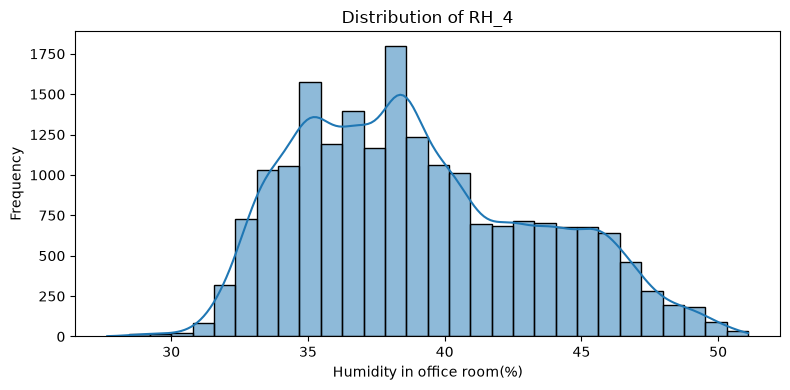

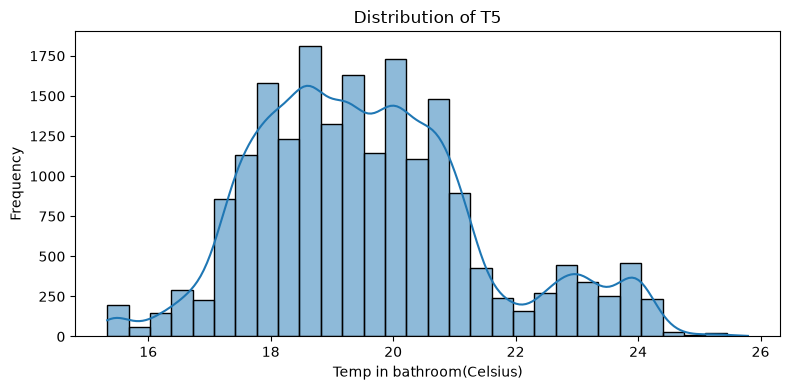

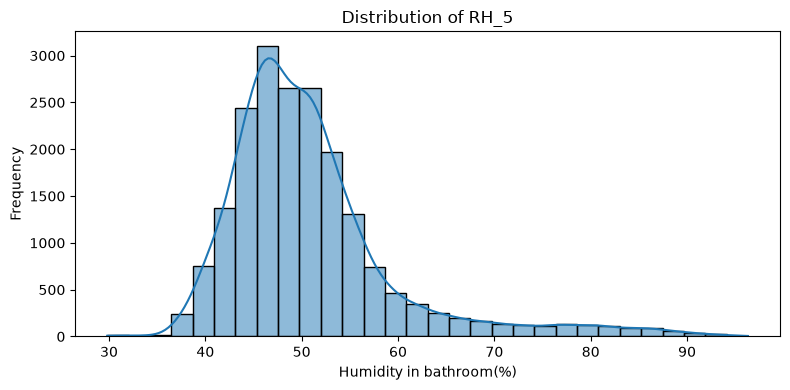

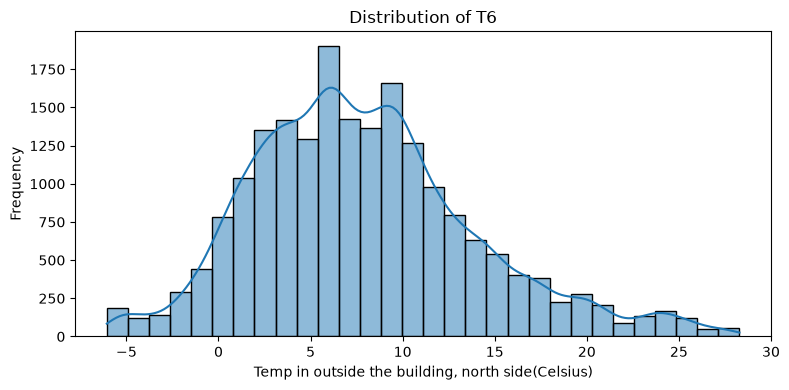

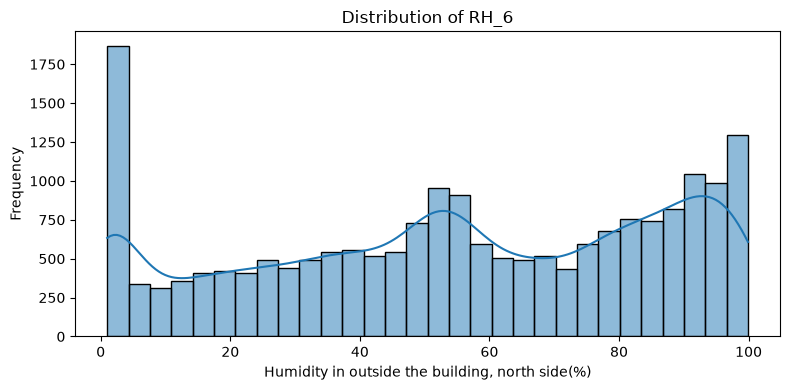

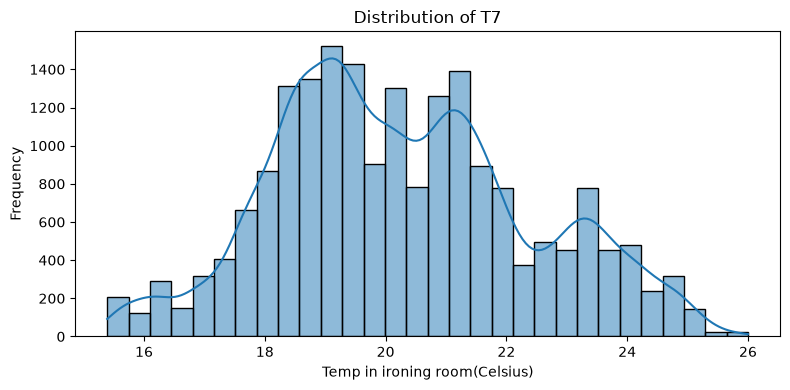

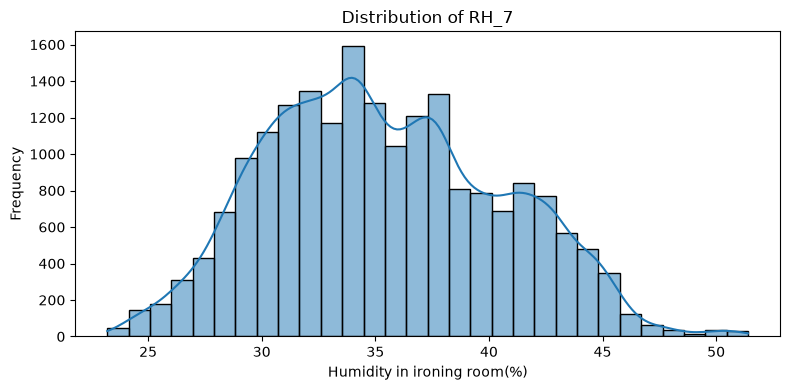

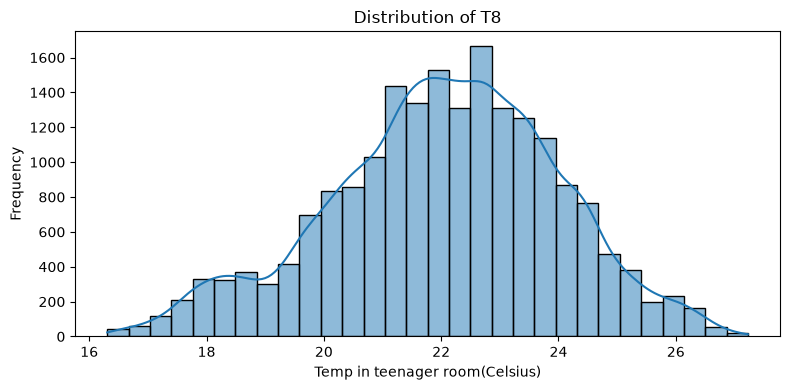

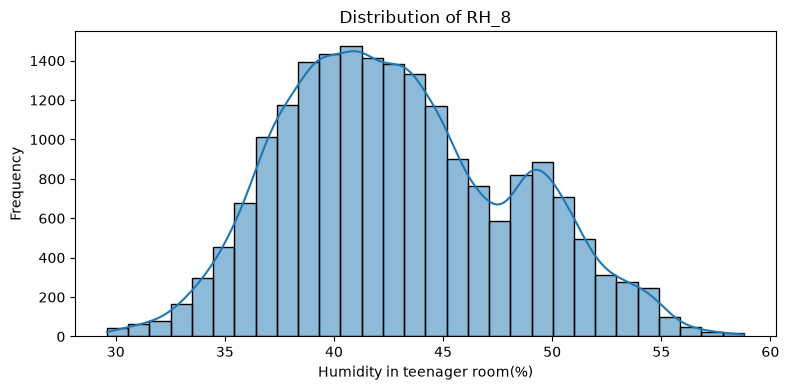

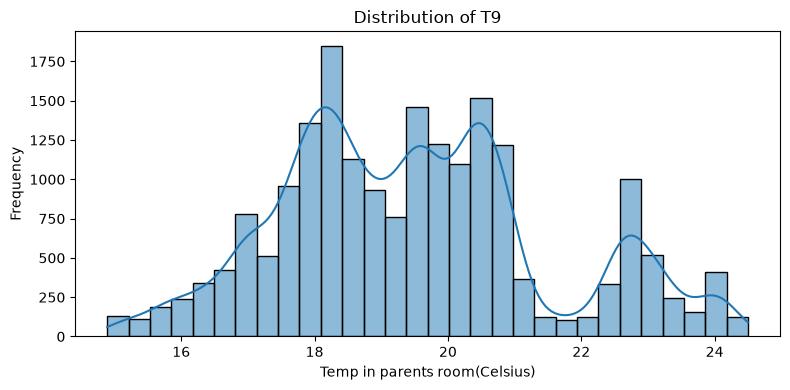

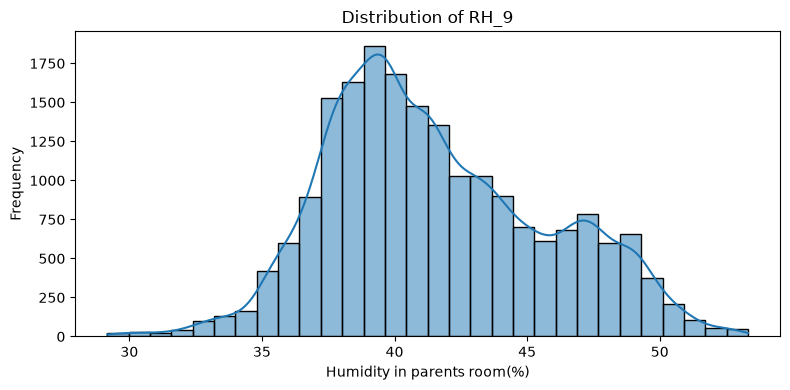

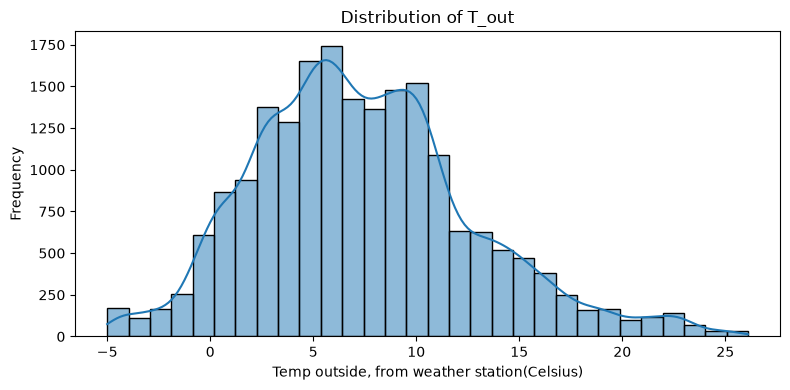

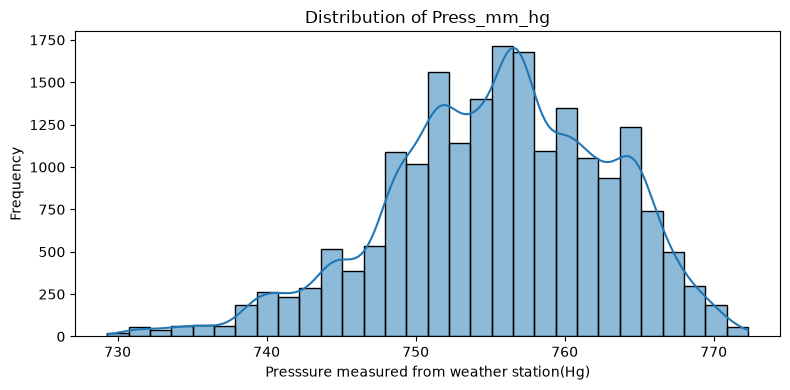

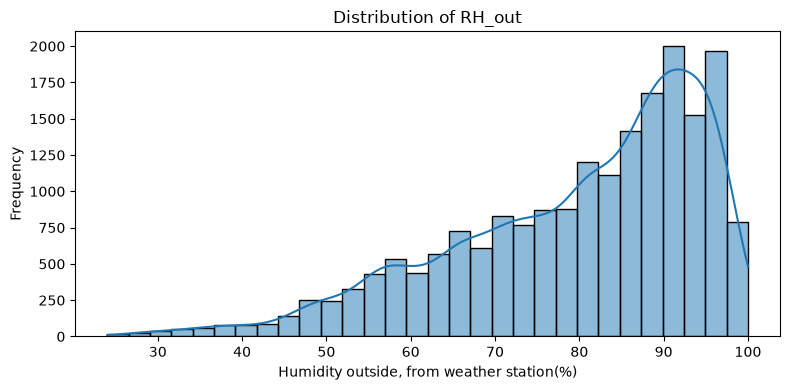

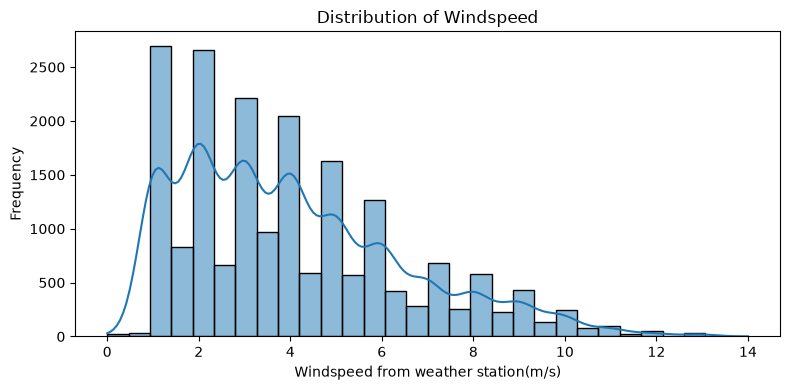

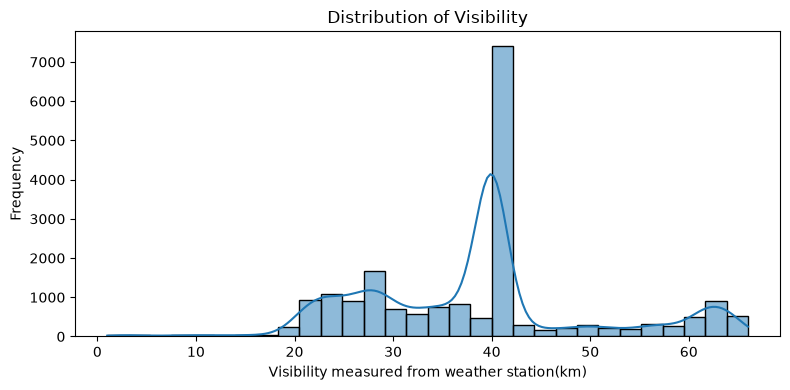

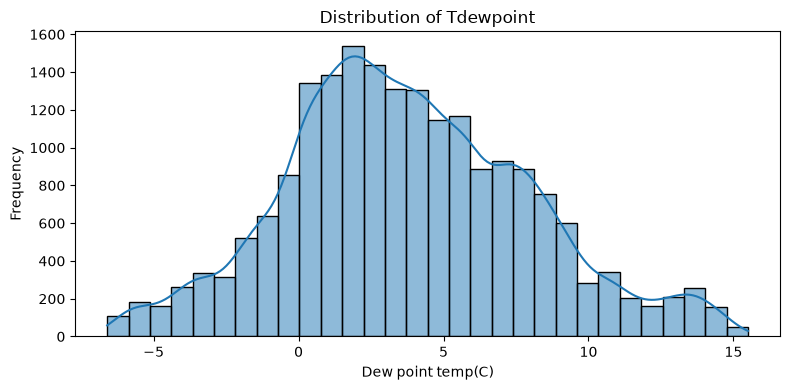

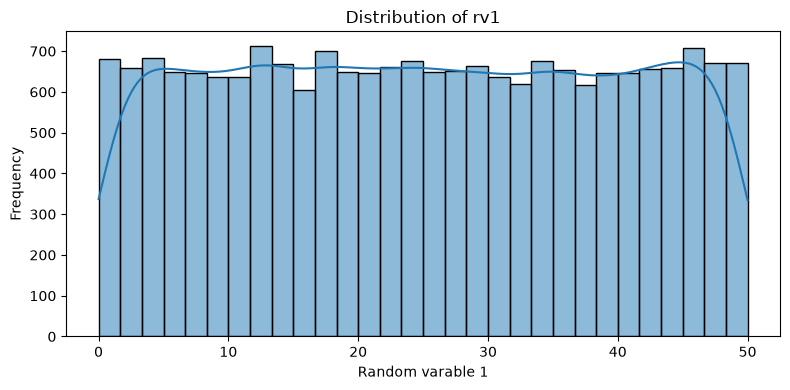

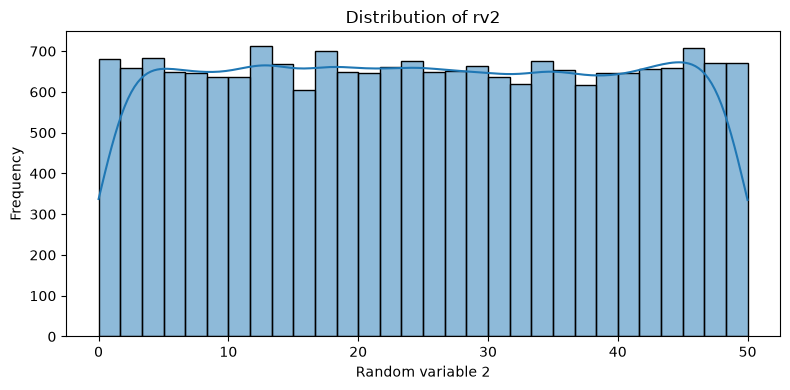



------------------------------------------




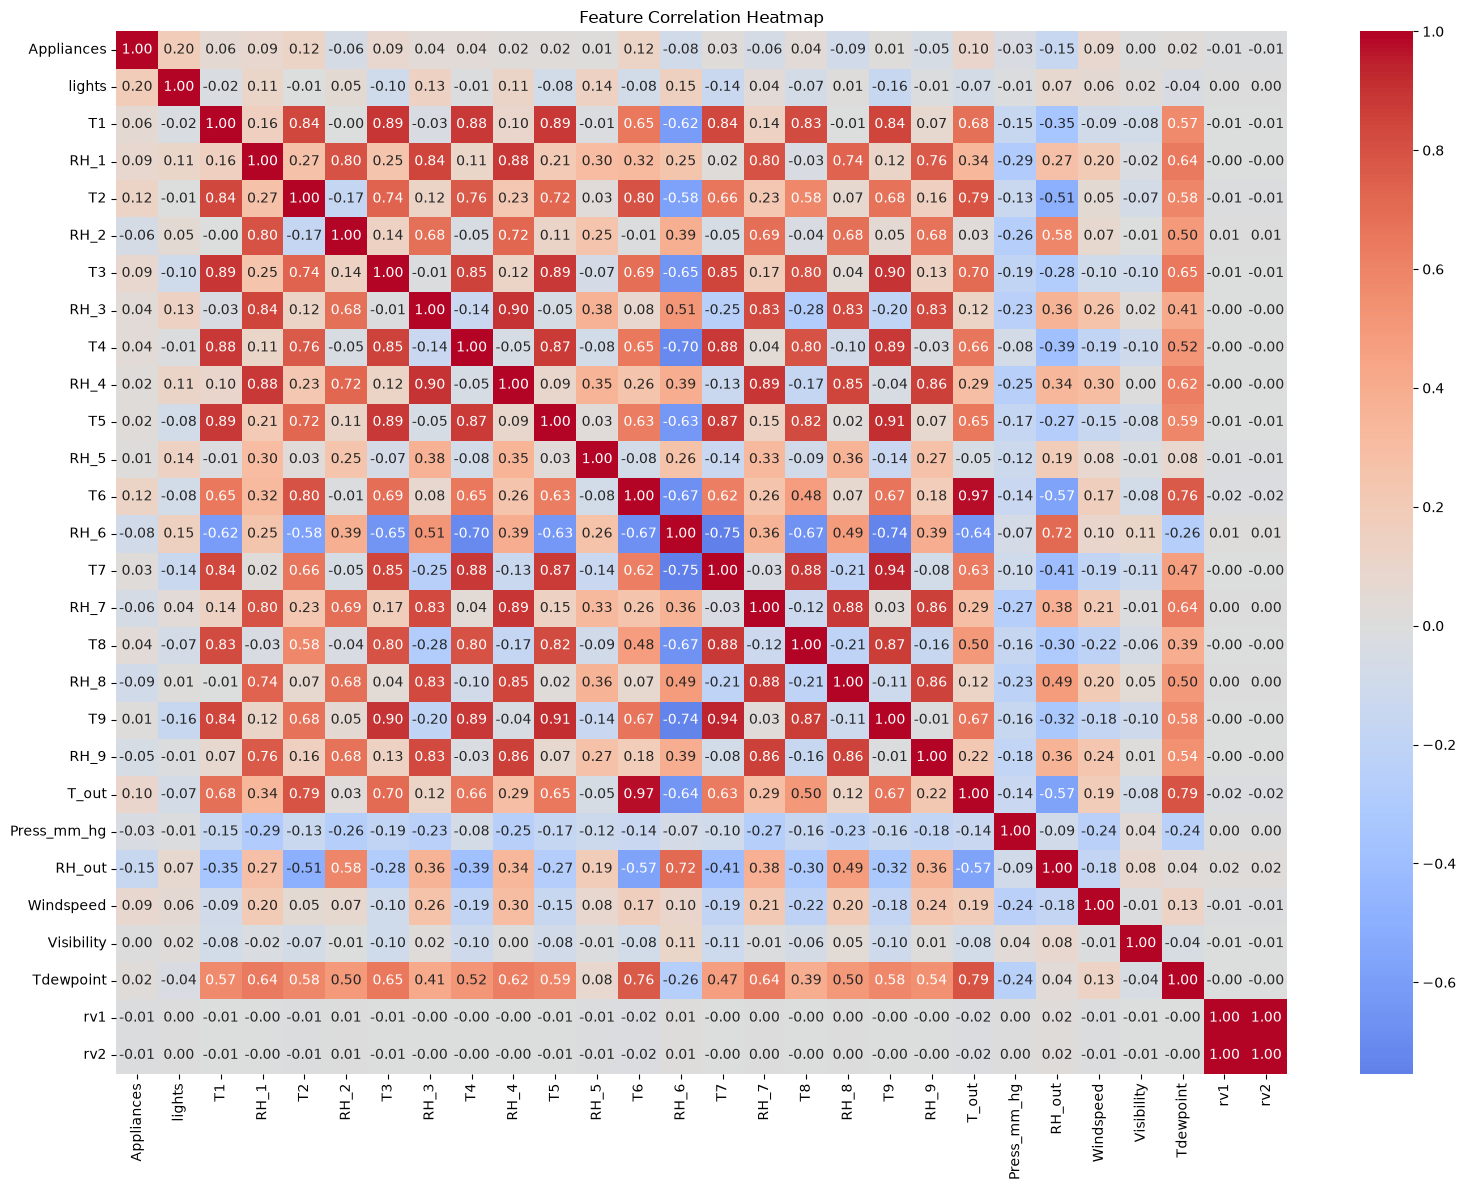



------------------------------------------




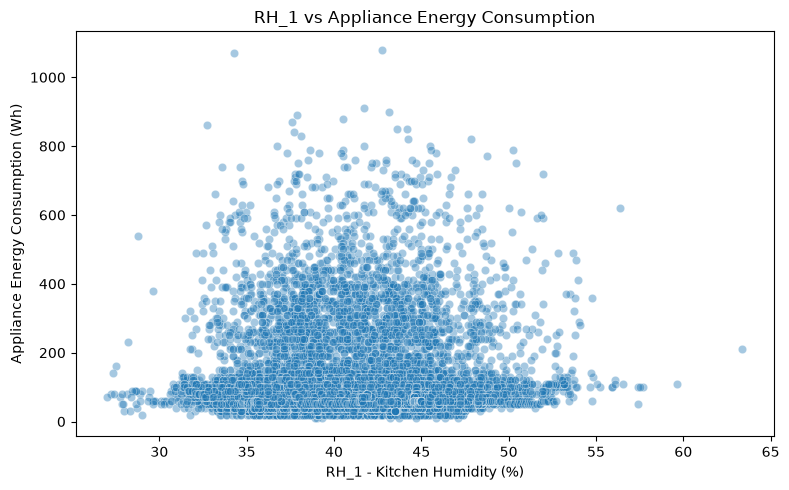

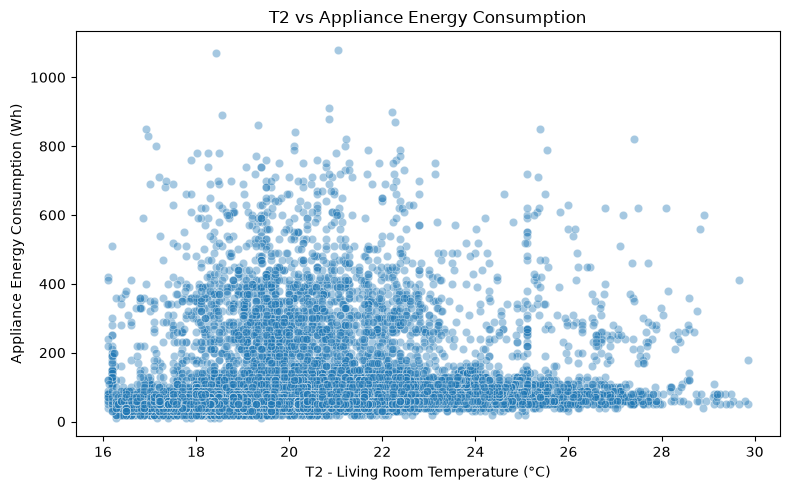

In [4]:
# Target Distribution
plt.figure(figsize=(10, 6))
df["Appliances"].plot(
    kind="hist",
    bins=30, # Divide the range into 30 bins
    edgecolor="black"
)

plt.xlabel("Appliance Energy Consumption (Wh)")
plt.ylabel("Number of Samples")
plt.title("Distribution of Appliance Energy Consumption")
plt.show()

print("\n\n------------------------------------------\n\n")

# Distribution plots for the features
feature_cols = df.select_dtypes(include="number").columns.drop("Appliances")
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.xlabel(col_to_name[col])
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()



print("\n\n------------------------------------------\n\n")

# Correlation map
plt.figure(figsize=(16, 12))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


print("\n\n------------------------------------------\n\n")

# Scattor between target and two features
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["RH_1"],
    y=df["Appliances"],
    alpha=0.4
)

plt.xlabel("RH_1 - Kitchen Humidity (%)")
plt.ylabel("Appliance Energy Consumption (Wh)")
plt.title("RH_1 vs Appliance Energy Consumption")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df["T2"],
    y=df["Appliances"],
    alpha=0.4
)

plt.xlabel("T2 - Living Room Temperature (°C)")
plt.ylabel("Appliance Energy Consumption (Wh)")
plt.title("T2 vs Appliance Energy Consumption")

plt.tight_layout()
plt.show()

## Interpretation and Analysis

### Target Distribution

- The majority of values of are between 0 and 200

### Feature Distribution

- Most of the features almost follow a statistical distribution like normal distribution

### Correlation Map

- Some highly corelated features exist like T_6(Temp outside the building) and T_out(Temp measured from weather station)
- Random variable 1 and 2 are also uncorelated to other features

# Data cleaning

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


-----------------------------------------


No.of duplicates: 0


-----------------------------------------




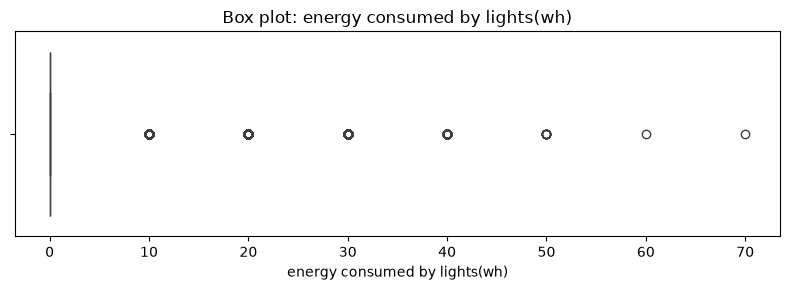

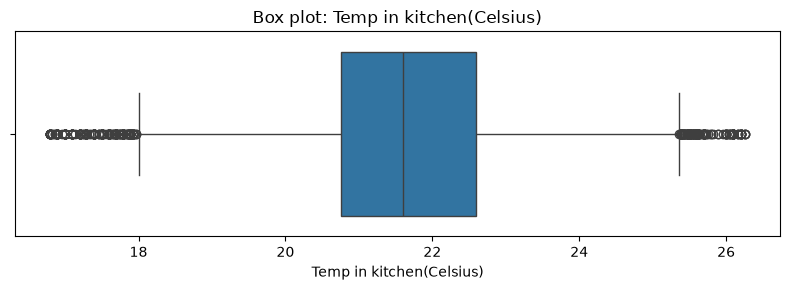

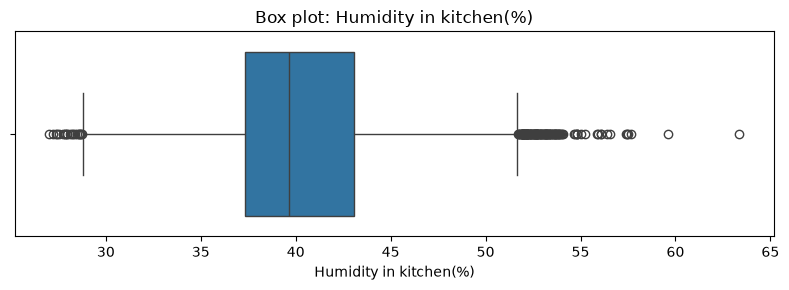

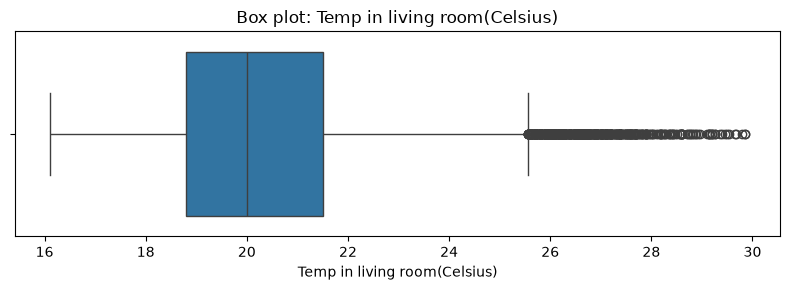

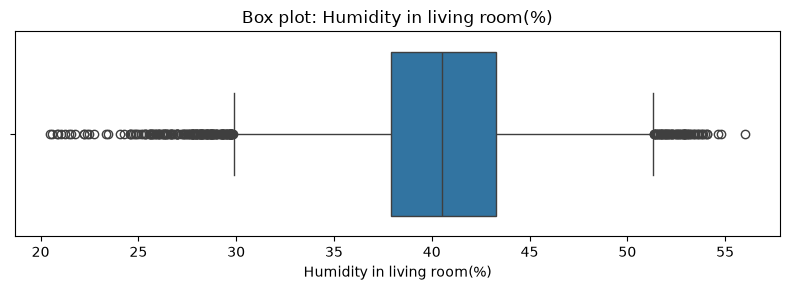

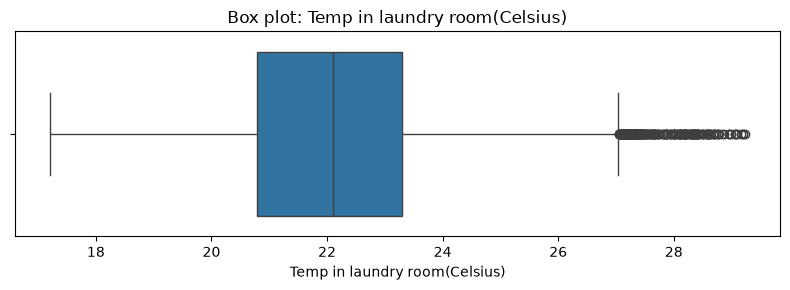

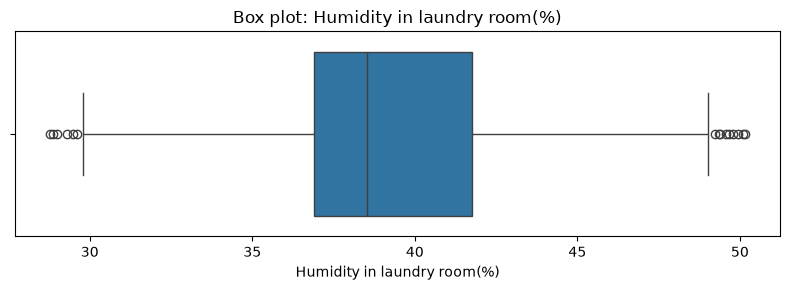

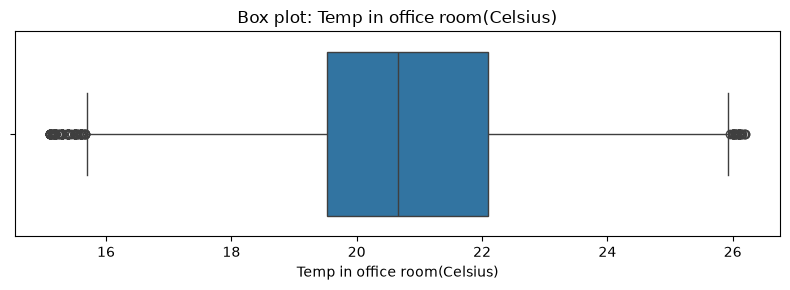

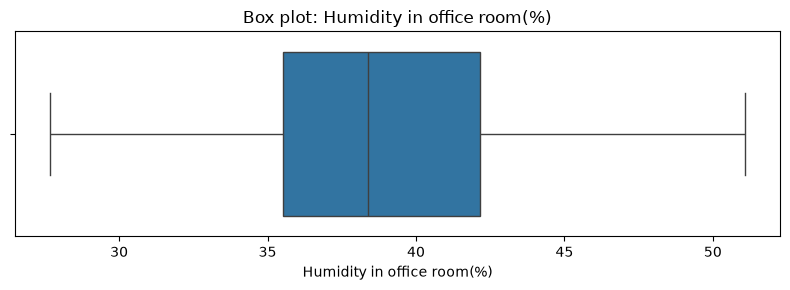

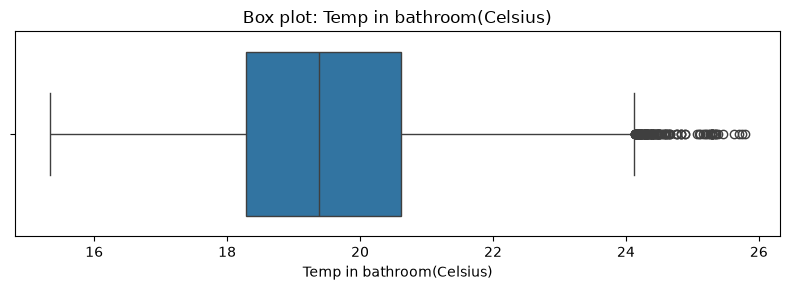

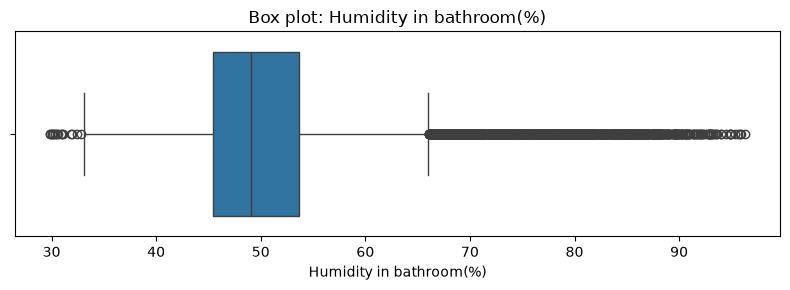

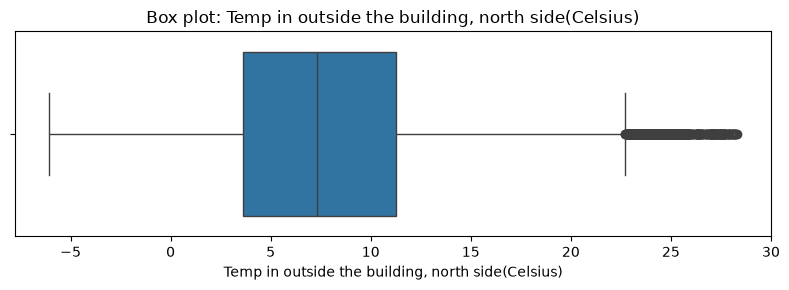

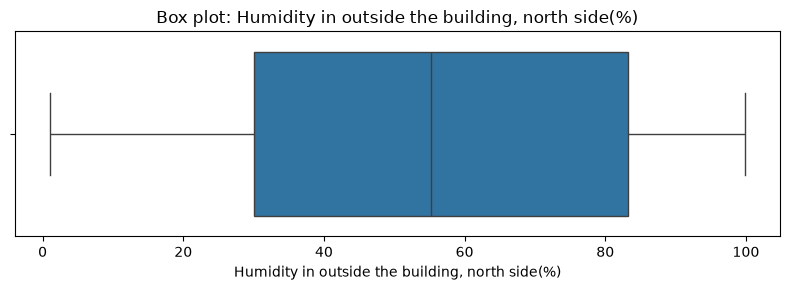

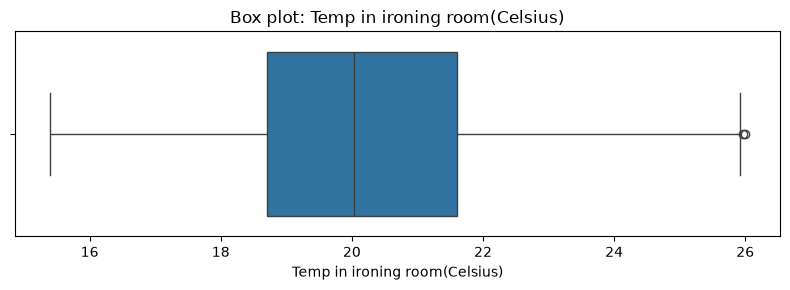

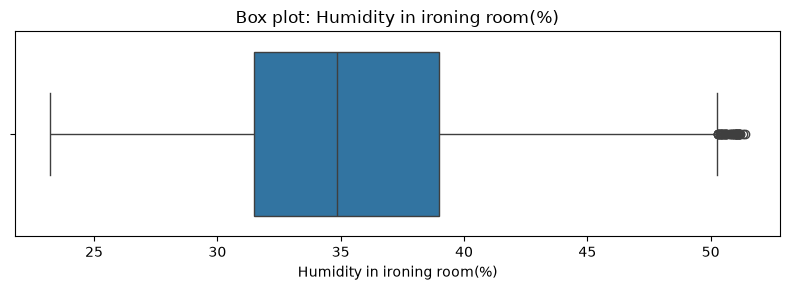

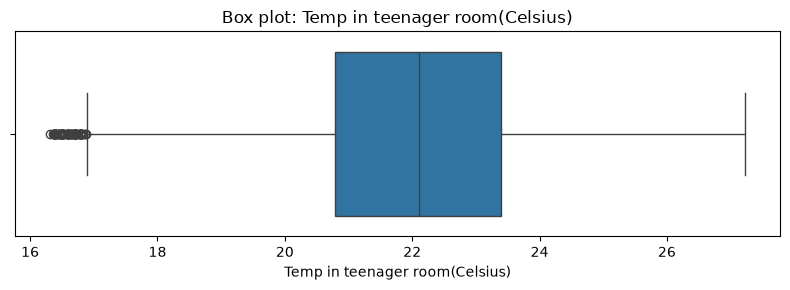

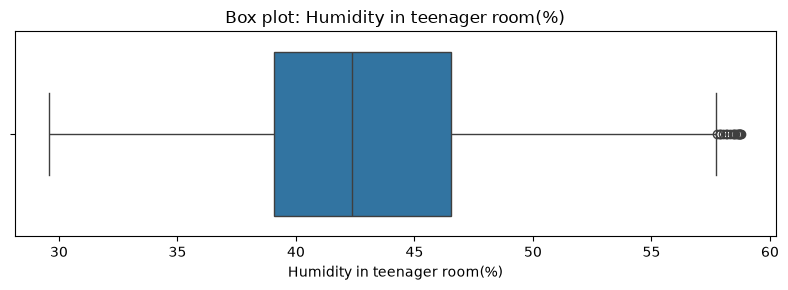

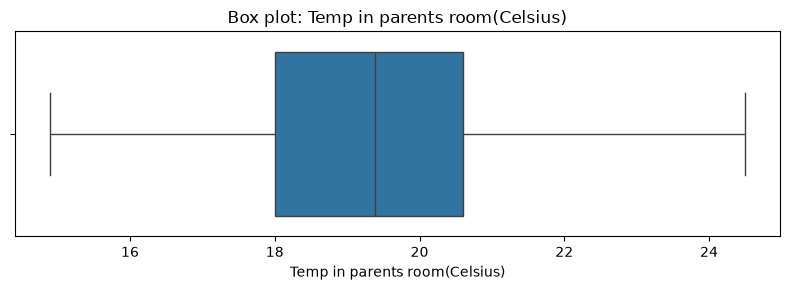

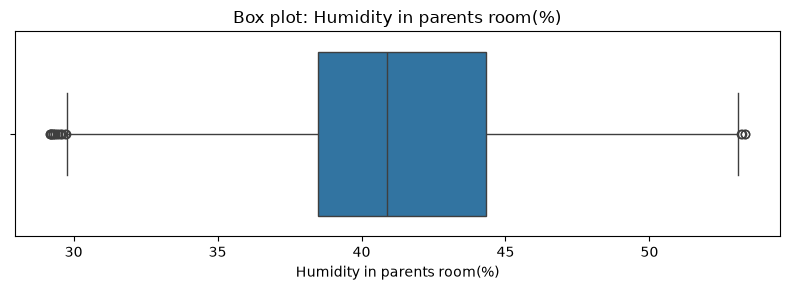

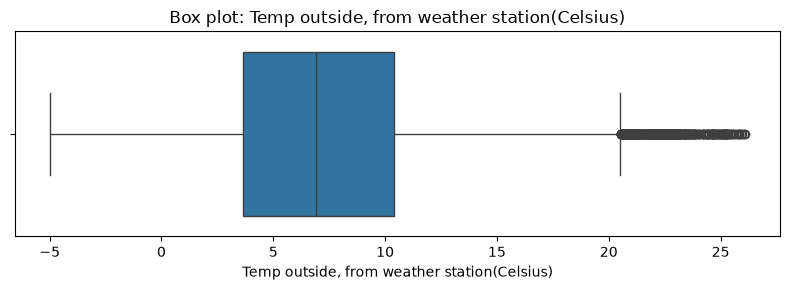

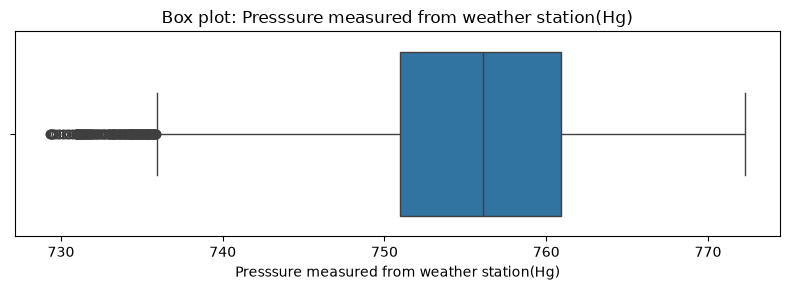

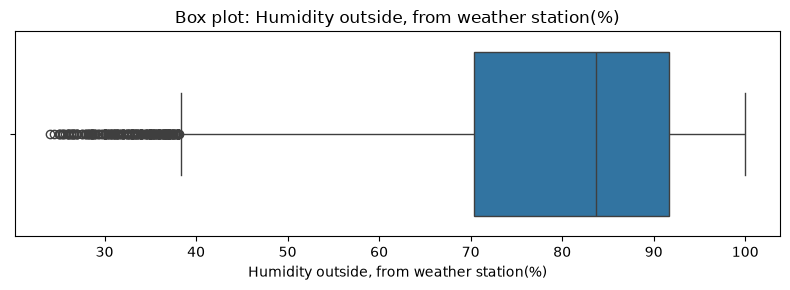

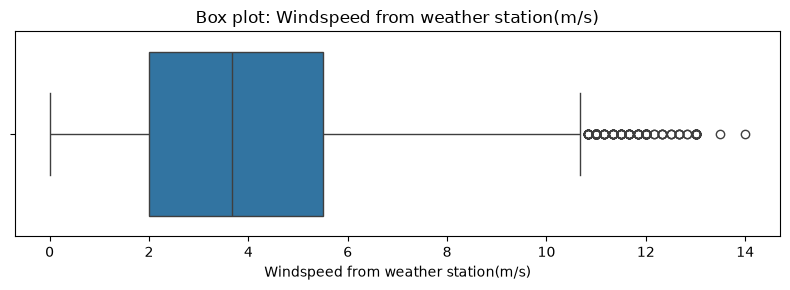

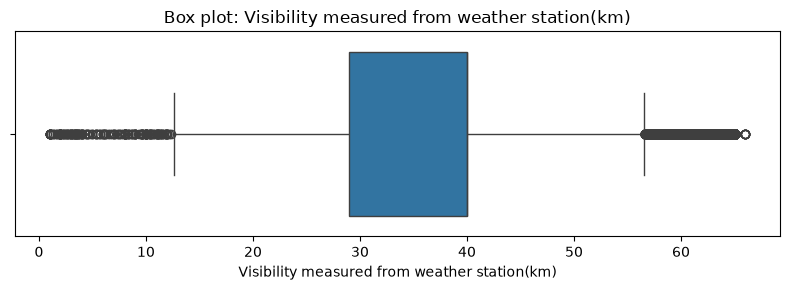

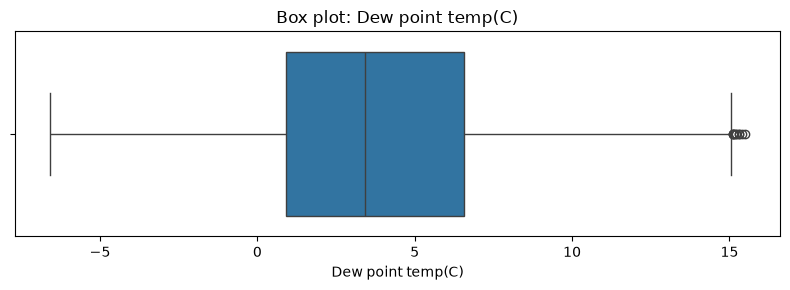

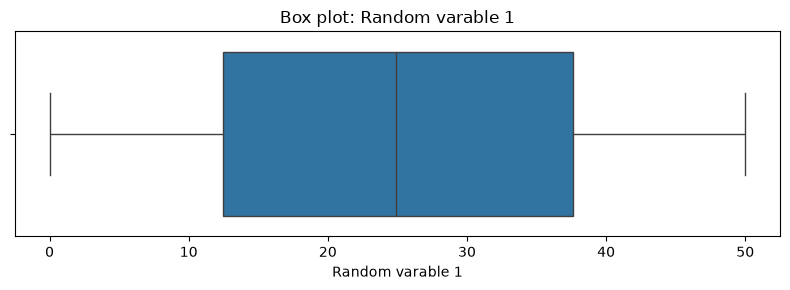

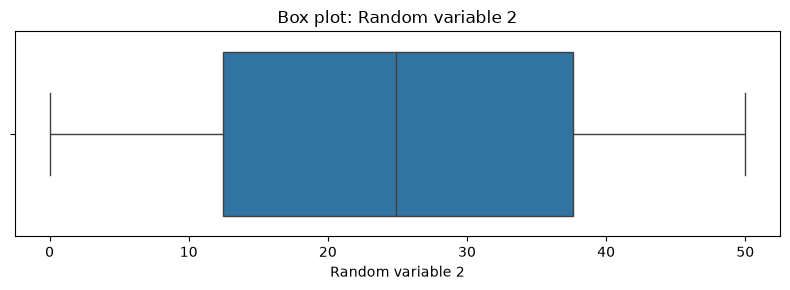

'\nQ1 = df["lights"].quantile(0.25)\nQ3 = df["lights"].quantile(0.75)\n\nIQR = Q3 - Q1\n\nlower = Q1 - 1.5 * IQR\nupper = Q3 + 1.5 * IQR\n\nremoved = df[\n    (df["lights"] < lower) |\n    (df["lights"] > upper)\n]\nprint(f"Lower: {lower}")\nprint(f"Upper: {upper}")\nprint(f"IQR: {IQR}")\nprint(f"Q3: {Q3}")\nprint(f"Q1: {Q1}")\nprint(removed.head())\nprint(df[\'lights\'].mean())\nprint(df["lights"].value_counts())\n'

In [5]:
print(df.isnull().sum())
rows = df.shape[0]

#TODO: Decide what to do about date
df.drop(labels=["date"],axis=1,inplace=True)
#columns.remove("date")


imputer = sk.impute.SimpleImputer(strategy="mean")
columns = list(df.columns)
columns.remove("Appliances")
for col in columns:
    if df[col].dtype in ["int64", "float64"]:
        df[col] = imputer.fit_transform(df[[col]])

print("\n\n-----------------------------------------\n\n")
print(f"No.of duplicates: {df.duplicated().sum()}")
print("\n\n-----------------------------------------\n\n")

for col in columns:

    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[col])

    plt.xlabel(col_to_name[col])
    plt.title(f"Box plot: {col_to_name[col]}")

    plt.tight_layout()
    plt.show()
    plt.close()


df["lights"] = np.log1p(df['lights']) # log(1+x) because there are a lot of 0, and log(0) is undefined

columns.remove("lights")
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)


"""
Q1 = df["lights"].quantile(0.25)
Q3 = df["lights"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

removed = df[
    (df["lights"] < lower) |
    (df["lights"] > upper)
]
print(f"Lower: {lower}")
print(f"Upper: {upper}")
print(f"IQR: {IQR}")
print(f"Q3: {Q3}")
print(f"Q1: {Q1}")
print(removed.head())
print(df['lights'].mean())
print(df["lights"].value_counts())
"""



# Feature Engineering

In [6]:
corr = df.corr(numeric_only=True)

threshold = 0.9
target = "Appliances"
to_remove = set()
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        feature1 = corr.columns[i]
        feature2 = corr.columns[j]
        correlation = corr.iloc[i, j]

        if feature1 == target or feature2 == target:
            continue

        if abs(correlation) > threshold:
            target_corr_1 = abs(corr.loc[feature1, target])
            target_corr_2 = abs(corr.loc[feature2, target])
            print(
                col_to_name[feature1],
                "<->",
                col_to_name[feature2],
                ":",
                correlation
            )

            if target_corr_1 < target_corr_2:
                print("Removing:", col_to_name[feature1])
                to_remove.add(feature1)
            else:
                print("Removing:", col_to_name[feature2])
                to_remove.add(feature2)
df.drop(labels=to_remove,axis=1,inplace=True)

Temp in laundry room(Celsius) <-> Temp in parents room(Celsius) : 0.9029312355483423
Removing: Temp in parents room(Celsius)
Temp in bathroom(Celsius) <-> Temp in parents room(Celsius) : 0.9115286756423487
Removing: Temp in parents room(Celsius)
Temp in outside the building, north side(Celsius) <-> Temp outside, from weather station(Celsius) : 0.97468072482053
Removing: Temp outside, from weather station(Celsius)
Temp in ironing room(Celsius) <-> Temp in parents room(Celsius) : 0.9447765228645182
Removing: Temp in parents room(Celsius)
Random varable 1 <-> Random variable 2 : 1.0
Removing: Random variable 2


## Justification for feature engineering

- Removing highly correlated features can improve performance mainly because redundant features can make some models harder to fit reliably.

- More features give the model more opportunities to fit random patterns/noise in the training data. Which may cause overfitting

- Removing highly corelated features can make the model simpler without losing much predictive information.

# Encoding, scaling & splitting

In [7]:
TEST_SIZE = 0.2

# Splitting
columns = list(df.columns)
columns.remove("Appliances")
target = df.drop(labels=columns,axis=1,inplace=False)
features = df.drop(labels=["Appliances"], axis=1, inplace=False)
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(features, target, test_size=TEST_SIZE,random_state=42)


# Scaling
scaler = sk.preprocessing.StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

# Linear Regression

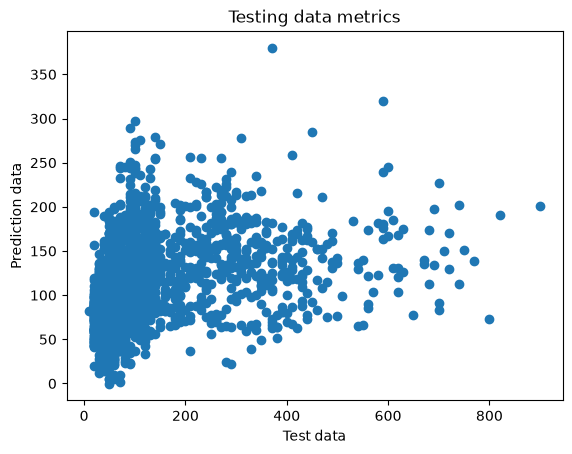

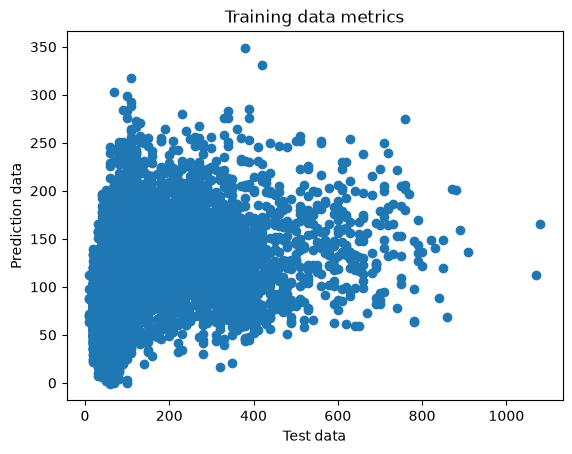



---------------------------------


Training data metrics: 
R2 score: 0.1578784832413438
RMSE score: 94.64230155279567
MAE score: 53.61557603713156


---------------------------------




---------------------------------


Testing data metrics: 
R2 score: 0.1638764787161786
RMSE score: 91.47220475847003
MAE score: 52.984614407374714


---------------------------------




In [ ]:
# Linear regression

linear_model_path = "../models/linear_regression.pkl"

#if os.path.exists(linear_model_path):
#    linear_model = joblib.load(linear_model_path)
#else:
#    linear_model = sk.linear_model.LinearRegression()
#    linear_model.fit(x_train,y_train)
#    joblib.dump(linear_model,linear_model_path)

linear_model = sk.linear_model.LinearRegression()
linear_model.fit(x_train,y_train)

y_test_pred = linear_model.predict(x_test)
y_train_pred = linear_model.predict(x_train)

plt.figure()
plt.scatter(y_test,y_test_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Testing data metrics")
plt.show()


plt.figure()
plt.scatter(y_train,y_train_pred)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Training data metrics")
plt.show()


r2_linear_train, rmse_linear_train, mae_linear_train = get_regression_scores(y_train,y_train_pred)
print("\n\n---------------------------------\n\n")
print(f"Training data metrics: ")
print(f"R2 score: {r2_linear_train}")
print(f"RMSE score: {rmse_linear_train}")
print(f"MAE score: {mae_linear_train}")

r2_linear_test, rmse_linear_test, mae_linear_test = get_regression_scores(y_test,y_test_pred)
print("\n\n---------------------------------\n\n")

print(f"Testing data metrics: ")
print(f"R2 score: {r2_linear_test}")
print(f"RMSE score: {rmse_linear_test}")
print(f"MAE score: {mae_linear_test}")




# Ridge Regression

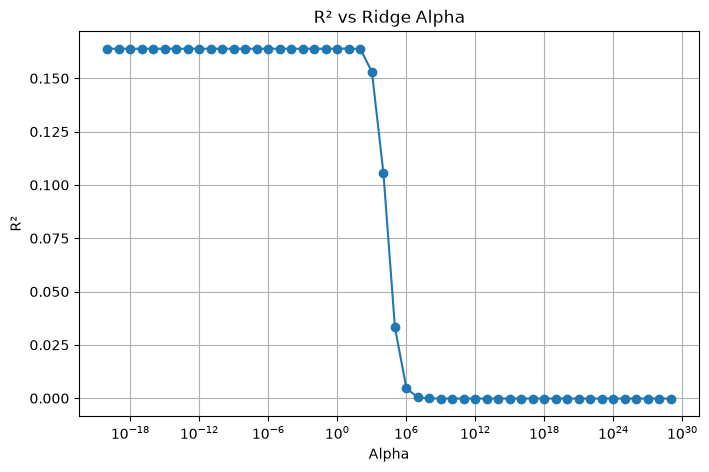

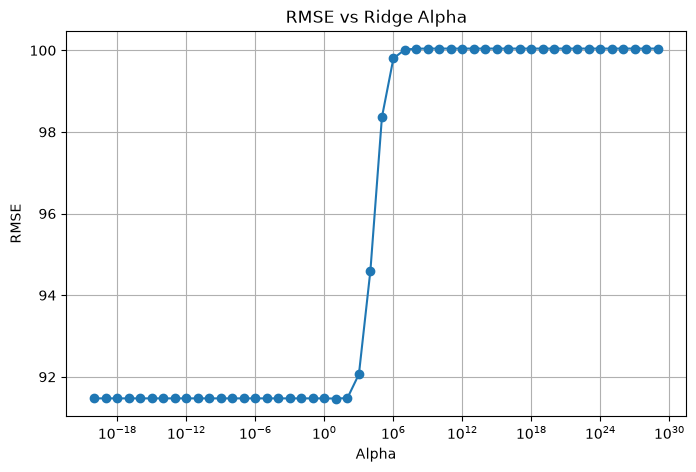

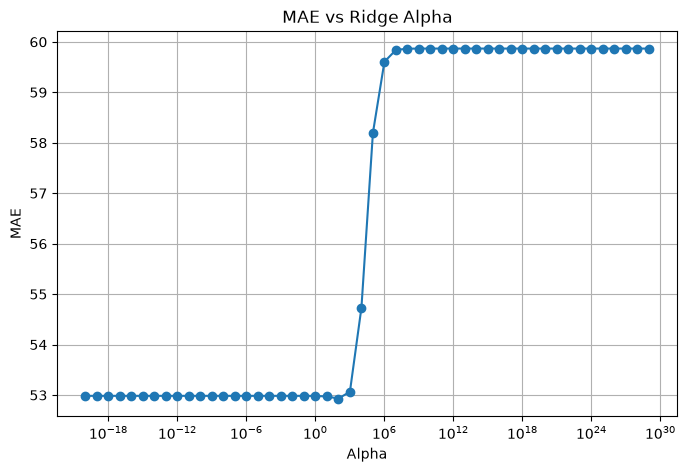

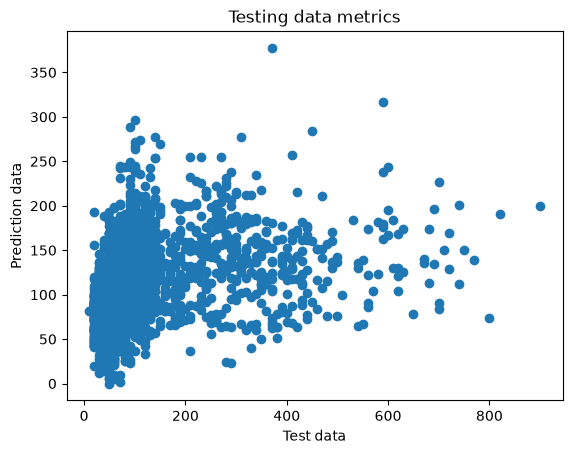

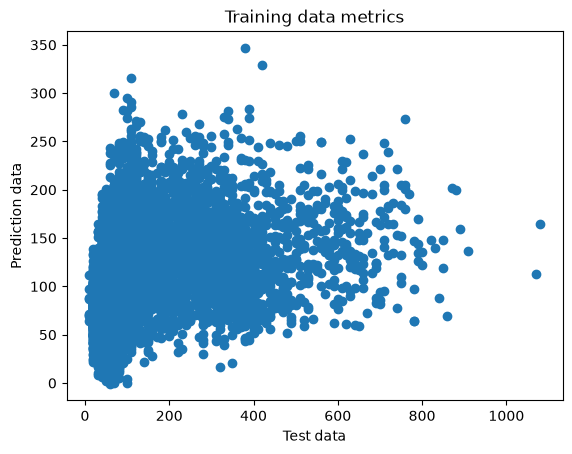



---------------------------------


Training data metrics: 
R2 score: 0.15786403089673462
RMSE score: 94.6431136667608
MAE score: 53.601601724798755


---------------------------------


Testing data metrics: 
R2 score: 0.16395337343639393
RMSE score: 91.46799850715888
MAE score: 52.9717709652605


In [37]:
# Ridge regression

SPLIT_TEST_SIZE = 0.2

alphas = []
results = []
alpha = 10**(-20)
for _ in range(50):
    alphas.append(alpha)
    model = sk.linear_model.Ridge(alpha=alpha)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)


    r2_temp, rmse_temp, mae_temp = get_regression_scores(y_test, y_pred)
    results.append((alpha,r2_temp,rmse_temp,mae_temp))

    alpha*= 10
    

results = np.array(results)
#print(results)
alphas = results[:, 0]
r2 = results[:, 1]
rmse = results[:, 2]
mae = results[:, 3]

# R² vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, r2, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("R² vs Ridge Alpha")
plt.grid(True)
plt.show()


# RMSE vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, rmse, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("RMSE vs Ridge Alpha")
plt.grid(True)
plt.show()


# MAE vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, mae, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("MAE vs Ridge Alpha")
plt.grid(True)
plt.show()


best_r2_idx_ridge = np.argmax(r2)
best_alpha_ridge = alphas[best_r2_idx_ridge]

ridge_model = sk.linear_model.Ridge(alpha=best_alpha_ridge)
ridge_model.fit(x_train,y_train)

y_pred_train_ridge = ridge_model.predict(x_train)
y_pred_test_ridge = ridge_model.predict(x_test)

r2_ridge_test, rmse_ridge_test, mae_ridge_test = get_regression_scores(y_test,y_pred_test_ridge)
r2_ridge_train, rmse_ridge_train, mae_ridge_train = get_regression_scores(y_train,y_pred_train_ridge)


plt.figure()
plt.scatter(y_test,y_pred_test_ridge)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Testing data metrics")
plt.show()


plt.figure()
plt.scatter(y_train,y_pred_train_ridge)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Training data metrics")
plt.show()


print("\n\n---------------------------------\n\n")
print(f"Training data metrics: ")
print(f"R2 score: {r2_ridge_train}")
print(f"RMSE score: {rmse_ridge_train}")
print(f"MAE score: {mae_ridge_train}")

print("\n\n---------------------------------\n\n")

print(f"Testing data metrics: ")
print(f"R2 score: {r2_ridge_test}")
print(f"RMSE score: {rmse_ridge_test}")
print(f"MAE score: {mae_ridge_test}")


# Lasso Regression

alpha=1e-05                zero features=0   non-zero features=24
alpha=1.610262027560939e-05 zero features=0   non-zero features=24
alpha=2.592943797404667e-05 zero features=0   non-zero features=24
alpha=4.1753189365604006e-05 zero features=0   non-zero features=24
alpha=6.723357536499335e-05 zero features=0   non-zero features=24
alpha=0.00010826367338740541 zero features=0   non-zero features=24
alpha=0.00017433288221999874 zero features=0   non-zero features=24
alpha=0.0002807216203941176 zero features=0   non-zero features=24
alpha=0.00045203536563602405 zero features=0   non-zero features=24
alpha=0.0007278953843983146 zero features=0   non-zero features=24
alpha=0.0011721022975334804 zero features=0   non-zero features=24
alpha=0.0018873918221350976 zero features=0   non-zero features=24
alpha=0.0030391953823131978 zero features=0   non-zero features=24
alpha=0.004893900918477494 zero features=0   non-zero features=24
alpha=0.007880462815669913 zero features=0   non-zero featur

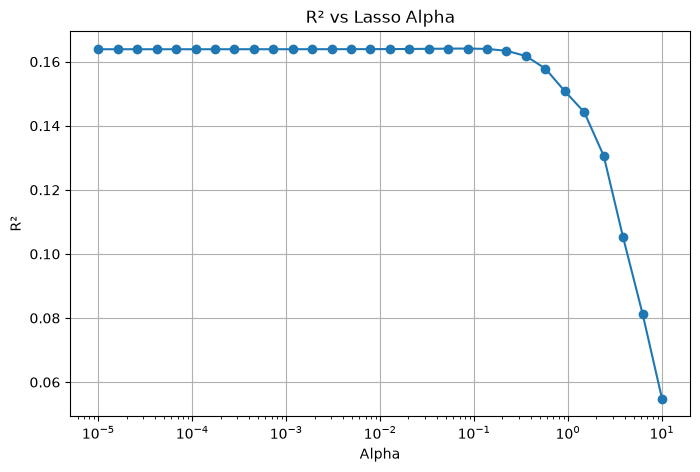

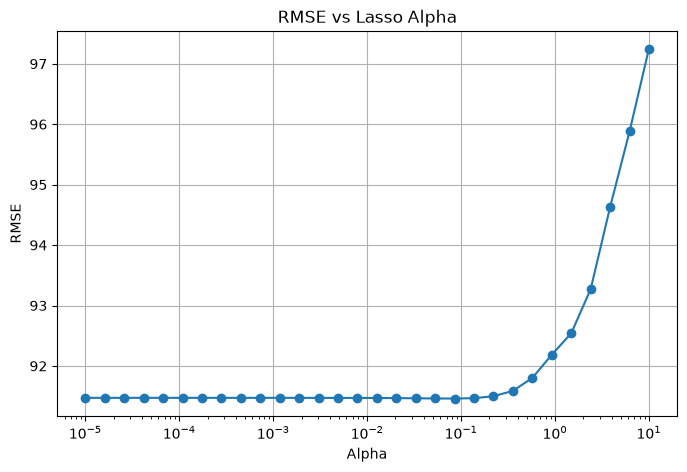

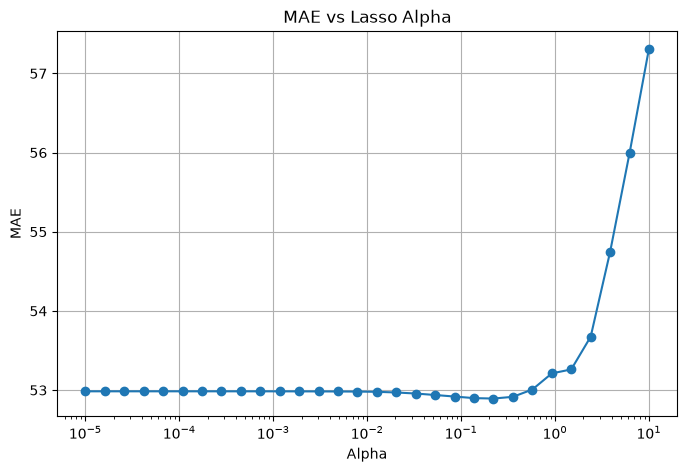

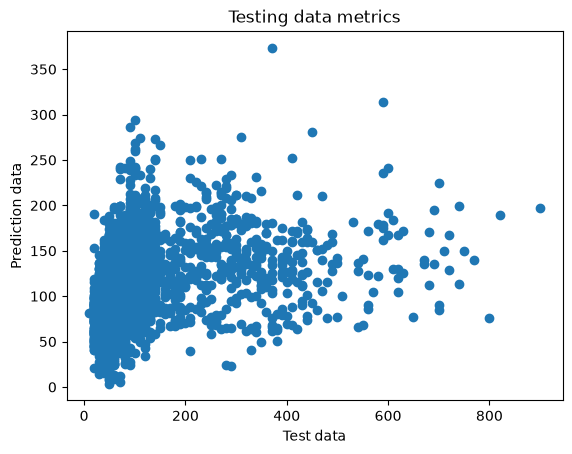

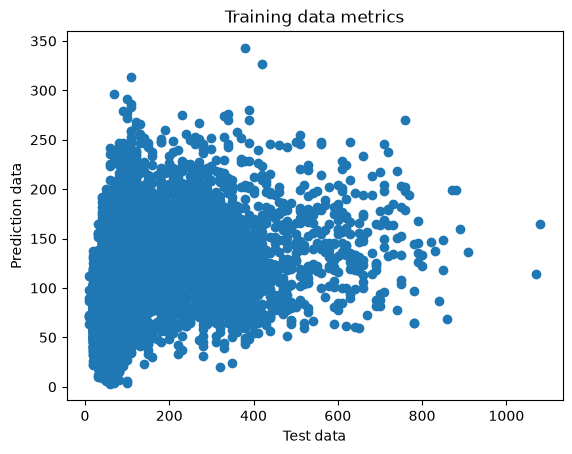



---------------------------------


Training data metrics: 
R2 score: 0.15764690792927527
RMSE score: 94.65531351933453
MAE score: 53.54741285132799


---------------------------------


Testing data metrics: 
R2 score: 0.16409256665526895
RMSE score: 91.46038394673762
MAE score: 52.918499508838174


In [17]:
# Lasso regression

results = [] # each element: (alpha, r2, rmse, mae)


for alpha in np.logspace(-5, 1, 30):
    lasso_model = sk.linear_model.Lasso(alpha=alpha)
    lasso_model.fit(x_train, y_train)

    zero = (lasso_model.coef_ == 0).sum()

    print(
        f"alpha={alpha:<20} "
        f"zero features={zero:<3} "
        f"non-zero features={len(lasso_model.coef_) - zero}"
    )

    
    y_pred = lasso_model.predict(x_test)

    r2,rmse,mae = get_regression_scores(y_test, y_pred)

    results.append((alpha, r2,rmse,mae))




results = np.array(results)
#print(results)
alphas = results[:, 0]
r2 = results[:, 1]
rmse = results[:, 2]
mae = results[:, 3]
    

# R² vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, r2, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("R² vs Lasso Alpha")
plt.grid(True)
plt.show()


# RMSE vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, rmse, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("RMSE vs Lasso Alpha")
plt.grid(True)
plt.show()


# MAE vs alpha
plt.figure(figsize=(8, 5))
plt.plot(alphas, mae, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("MAE vs Lasso Alpha")
plt.grid(True)
plt.show()


best_r2_idx_lasso = np.argmax(r2)
best_alpha_lasso = alphas[best_r2_idx_lasso]

lasso_model = sk.linear_model.Lasso(alpha=best_alpha_lasso)
lasso_model.fit(x_train,y_train)

y_pred_train_lasso = lasso_model.predict(x_train)
y_pred_test_lasso = lasso_model.predict(x_test)

r2_lasso_test, rmse_lasso_test, mae_lasso_test = get_regression_scores(y_test,y_pred_test_lasso)
r2_lasso_train, rmse_lasso_train, mae_lasso_train = get_regression_scores(y_train,y_pred_train_lasso)


plt.figure()
plt.scatter(y_test,y_pred_test_lasso)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Testing data metrics")
plt.show()


plt.figure()
plt.scatter(y_train,y_pred_train_lasso)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Training data metrics")
plt.show()


print("\n\n---------------------------------\n\n")
print(f"Training data metrics: ")
print(f"R2 score: {r2_lasso_train}")
print(f"RMSE score: {rmse_lasso_train}")
print(f"MAE score: {mae_lasso_train}")

print("\n\n---------------------------------\n\n")

print(f"Testing data metrics: ")
print(f"R2 score: {r2_lasso_test}")
print(f"RMSE score: {rmse_lasso_test}")
print(f"MAE score: {mae_lasso_test}")

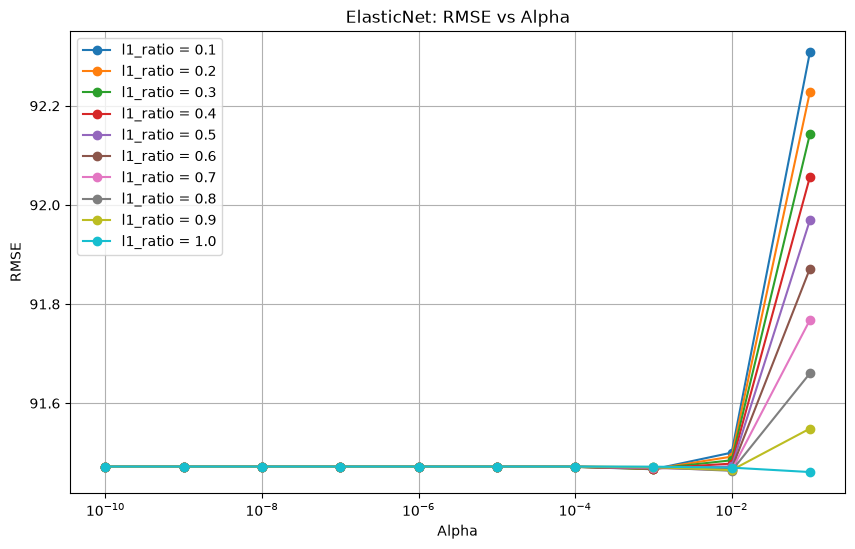

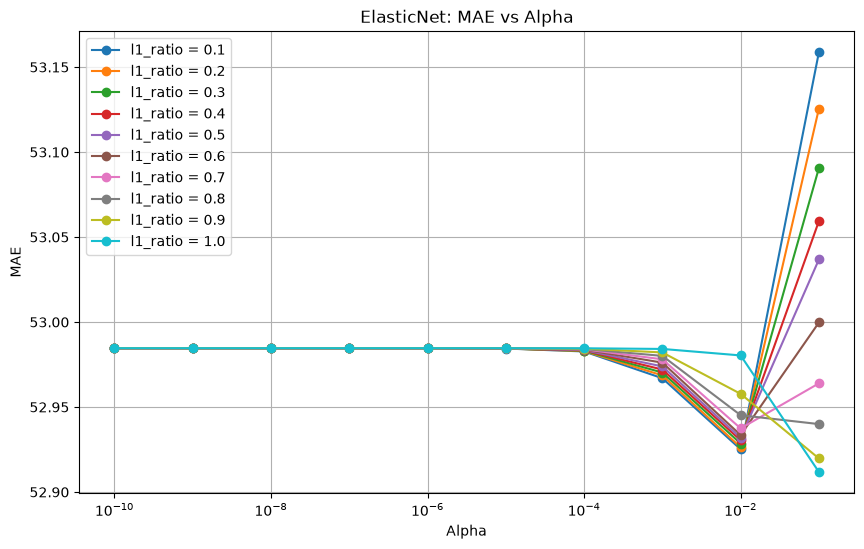

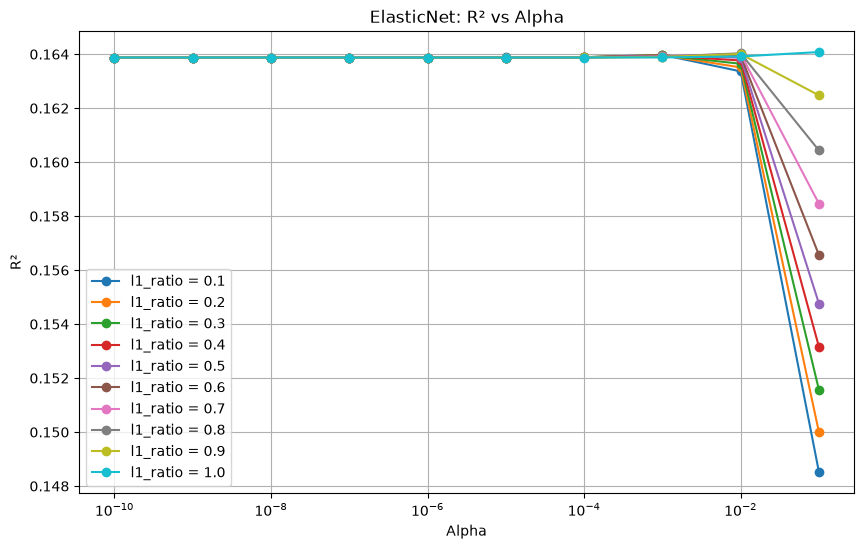

Best alpha: 0.1
Best l1_ratio: 0.9999999999999999
Best R²: 0.1640796206941897


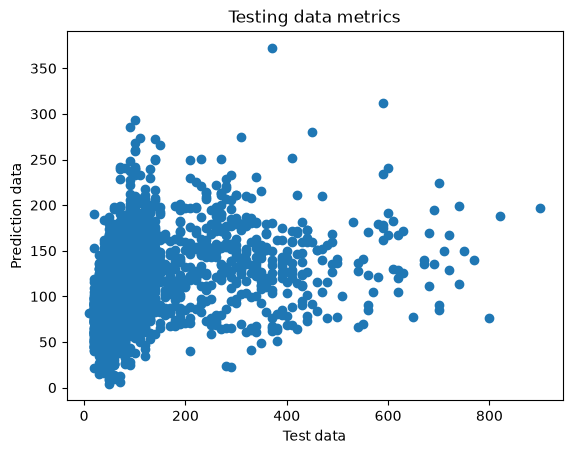

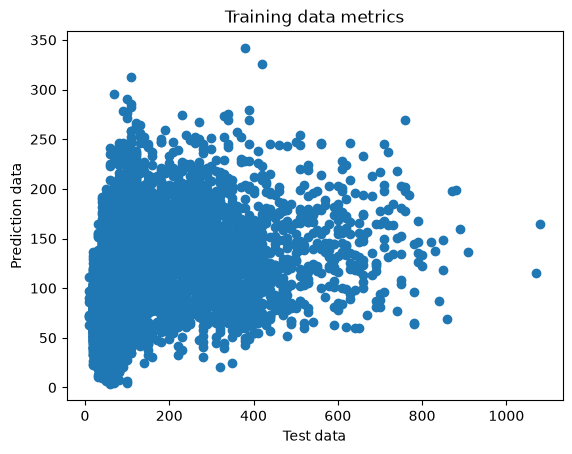



---------------------------------


Training data metrics: 
R2 score: 0.15756037891454033
RMSE score: 94.66017503214299
MAE score: 53.5400801312287


---------------------------------


Testing data metrics: 
R2 score: 0.1640796206941897
RMSE score: 91.46109218184792
MAE score: 52.91175247805097


In [20]:
# ElasticNet regression


results = [] #each element: (l1_ratio, alpha, rmse, mae, r2)
alpha = 10**(-10)
l1_ratio = 0.1

for _ in range(10):
    alpha = 10**(-10)
    for _ in range(10):
        model_path = f"../models/elasticNet_l1_ratio_{l1_ratio}_alpha_{alpha}.pkl"
        if os.path.exists(model_path):
            model = joblib.load(model_path)
        else:
            model = sk.linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio)
            model.fit(x_train,y_train)
            joblib.dump(model, model_path)

        #model = sk.linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio)
        #model.fit(x_train,y_train)
        y_pred = model.predict(x_test)
        r2, rmse, mae = get_regression_scores(y_test,y_pred)
        results.append((l1_ratio,alpha, rmse, mae, r2))
        alpha*=10
    l1_ratio+=0.1


results = np.array(results)

l1_ratios = results[:, 0]
alphas = results[:, 1]
rmse = results[:, 2]
mae = results[:, 3]
r2 = results[:, 4]


plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        rmse[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("ElasticNet: RMSE vs Alpha")
plt.legend()
plt.grid(True)

plt.show()

# MAE plot
plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        mae[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("MAE")
plt.title("ElasticNet: MAE vs Alpha")
plt.legend()
plt.grid(True)

plt.show()

# R² plot
plt.figure(figsize=(10, 6))

for ratio in np.unique(l1_ratios):
    mask = l1_ratios == ratio

    plt.plot(
        alphas[mask],
        r2[mask],
        marker='o',
        label=f"l1_ratio = {ratio:.1f}"
    )

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R²")
plt.title("ElasticNet: R² vs Alpha")
plt.legend()
plt.grid(True)
plt.show()


best_idx_elastic_net = np.argmax(r2)

best_alpha_elastic_net = alphas[best_idx_elastic_net]
best_l1_ratio_elastic_net = l1_ratios[best_idx_elastic_net]
best_r2_elastic_net = r2[best_idx_elastic_net]

print("Best alpha:", best_alpha_elastic_net)
print("Best l1_ratio:", best_l1_ratio_elastic_net)
print("Best R²:", best_r2_elastic_net)

elastic_net_model = sk.linear_model.ElasticNet(alpha=best_alpha_elastic_net, l1_ratio=best_l1_ratio_elastic_net)
elastic_net_model.fit(x_train,y_train)

y_pred_train_elastic_net = elastic_net_model.predict(x_train)
y_pred_test_elastic_net = elastic_net_model.predict(x_test)

r2_elastic_net_test, rmse_elastic_net_test, mae_elastic_net_test = get_regression_scores(y_test,y_pred_test_elastic_net)
r2_elastic_net_train, rmse_elastic_net_train, mae_elastic_net_train = get_regression_scores(y_train,y_pred_train_elastic_net)


plt.figure()
plt.scatter(y_test,y_pred_test_elastic_net)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Testing data metrics")
plt.show()


plt.figure()
plt.scatter(y_train,y_pred_train_elastic_net)
plt.xlabel(f"Test data")
plt.ylabel(f"Prediction data")
plt.title("Training data metrics")
plt.show()


print("\n\n---------------------------------\n\n")
print(f"Training data metrics: ")
print(f"R2 score: {r2_elastic_net_train}")
print(f"RMSE score: {rmse_elastic_net_train}")
print(f"MAE score: {mae_elastic_net_train}")

print("\n\n---------------------------------\n\n")

print(f"Testing data metrics: ")
print(f"R2 score: {r2_elastic_net_test}")
print(f"RMSE score: {rmse_elastic_net_test}")
print(f"MAE score: {mae_elastic_net_test}")



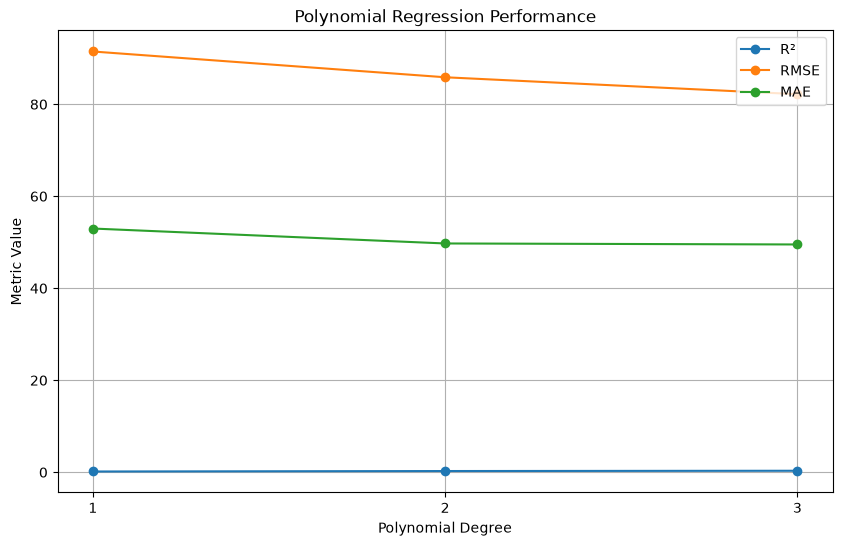

Best degree: 3
Best R²: 0.3249683571278027


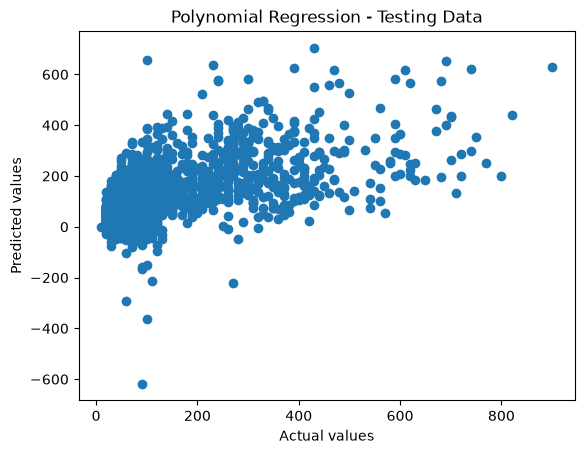

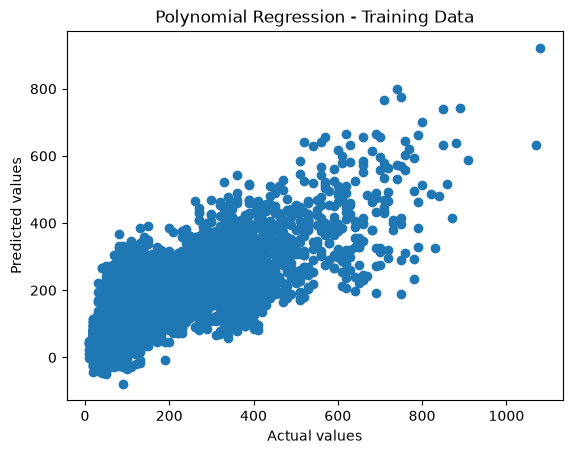



---------------------------------


Training data metrics:
R2 score: 0.6690993533921594
RMSE score: 59.32622561242697
MAE score: 36.993940113027385


---------------------------------


Testing data metrics:
R2 score: 0.3249683571278027
RMSE score: 82.18943448884845
MAE score: 49.520332397779335


In [24]:
# Polynomial Regression


degrees = range(1, 4)

results = [] #each element: (degree, r2,rmse,mae)

for degree in degrees:

    model_path = f"../models/poly_regression_degree_{degree}.pkl"
    if os.path.exists(model_path):
        poly, scaler, model = joblib.load(model_path)
    else:
        poly = sk.preprocessing.PolynomialFeatures(degree=degree)
        poly.fit(x_train)
        scaler = sk.preprocessing.StandardScaler()
        model = sk.linear_model.LinearRegression()
        x_train_poly = poly.transform(x_train)
        x_test_poly = poly.transform(x_test)
        scaler.fit(x_train_poly)
        x_train_scaled = scaler.transform(x_train_poly)
        x_test_scaled = scaler.transform(x_test_poly)
        model.fit(x_train_scaled,y_train)
        joblib.dump((poly, scaler, model),model_path)
    """

    poly = sk.preprocessing.PolynomialFeatures(degree=degree)
    poly.fit(x_train)
    scaler = sk.preprocessing.StandardScaler()
    model = sk.linear_model.LinearRegression()
    x_train_poly = poly.transform(x_train)
    x_test_poly = poly.transform(x_test)
    scaler.fit(x_train_poly)
    x_train_scaled = scaler.transform(x_train_poly)
    x_test_scaled = scaler.transform(x_test_poly)
    model.fit(x_train_scaled,y_train)
    """
    
    
    x_test_poly = poly.transform(x_test)
    x_test_scaled = scaler.transform(x_test_poly)
    
    y_pred = model.predict(x_test_scaled)
    
    rmse = np.sqrt(sk.metrics.mean_squared_error(y_test, y_pred))
    mae = sk.metrics.mean_absolute_error(y_test, y_pred)
    r2 = sk.metrics.r2_score(y_test, y_pred)

    results.append((degree, r2, rmse, mae))

results = np.array(results)

degrees_plot = results[:, 0]
r2 = results[:, 1]
rmse = results[:, 2]
mae = results[:, 3]

plt.figure(figsize=(10, 6))

plt.plot(degrees_plot, r2, marker="o", label="R²")
plt.plot(degrees_plot, rmse, marker="o", label="RMSE")
plt.plot(degrees_plot, mae, marker="o", label="MAE")

plt.xlabel("Polynomial Degree")
plt.ylabel("Metric Value")
plt.title("Polynomial Regression Performance")
plt.xticks(degrees_plot)
plt.legend()
plt.grid(True)
plt.show()

best_idx_poly = np.argmax(r2)

best_degree_poly = int(degrees_plot[best_idx_poly])
best_r2_poly = r2[best_idx_poly]

print("Best degree:", best_degree_poly)
print("Best R²:", best_r2_poly)


# Create polynomial features
poly = sk.preprocessing.PolynomialFeatures(degree=best_degree_poly)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Scale polynomial features
scaler = sk.preprocessing.StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_poly)
x_test_scaled = scaler.transform(x_test_poly)


# Train model
poly_model = sk.linear_model.LinearRegression()

poly_model.fit(x_train_scaled, y_train)


# Predictions
y_pred_train_poly = poly_model.predict(x_train_scaled)
y_pred_test_poly = poly_model.predict(x_test_scaled)


# Metrics
r2_poly_test, rmse_poly_test, mae_poly_test = \
    get_regression_scores(y_test, y_pred_test_poly)

r2_poly_train, rmse_poly_train, mae_poly_train = \
    get_regression_scores(y_train, y_pred_train_poly)


# Test scatter plot
plt.figure()

plt.scatter(y_test, y_pred_test_poly)

plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Polynomial Regression - Testing Data")

plt.show()


# Train scatter plot
plt.figure()

plt.scatter(y_train, y_pred_train_poly)

plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Polynomial Regression - Training Data")

plt.show()


print("\n\n---------------------------------\n\n")

print("Training data metrics:")

print(f"R2 score: {r2_poly_train}")
print(f"RMSE score: {rmse_poly_train}")
print(f"MAE score: {mae_poly_train}")


print("\n\n---------------------------------\n\n")

print("Testing data metrics:")

print(f"R2 score: {r2_poly_test}")
print(f"RMSE score: {rmse_poly_test}")
print(f"MAE score: {mae_poly_test}")